/tmp/ipykernel_1070/2933422850.py:81: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1070/2933422850.py:81: UserWarning: Glyph 48276 (\N{HANGUL SYLLABLE BEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1070/2933422850.py:81: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1070/2933422850.py:81: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1070/2933422850.py:81: UserWarning: Glyph 44305 (\N{HANGUL SYLLABLE GWANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1070/2933422850.py:81: UserWarning: Glyph 50669 (\N{HANGUL SYLLABLE YEOG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1070/2933422850.py:81: UserWarning: Glyph 44048 (\N{HANGUL SYLLABLE GAM}) missing from font(s) DejaVu Sans.
  plt.tight

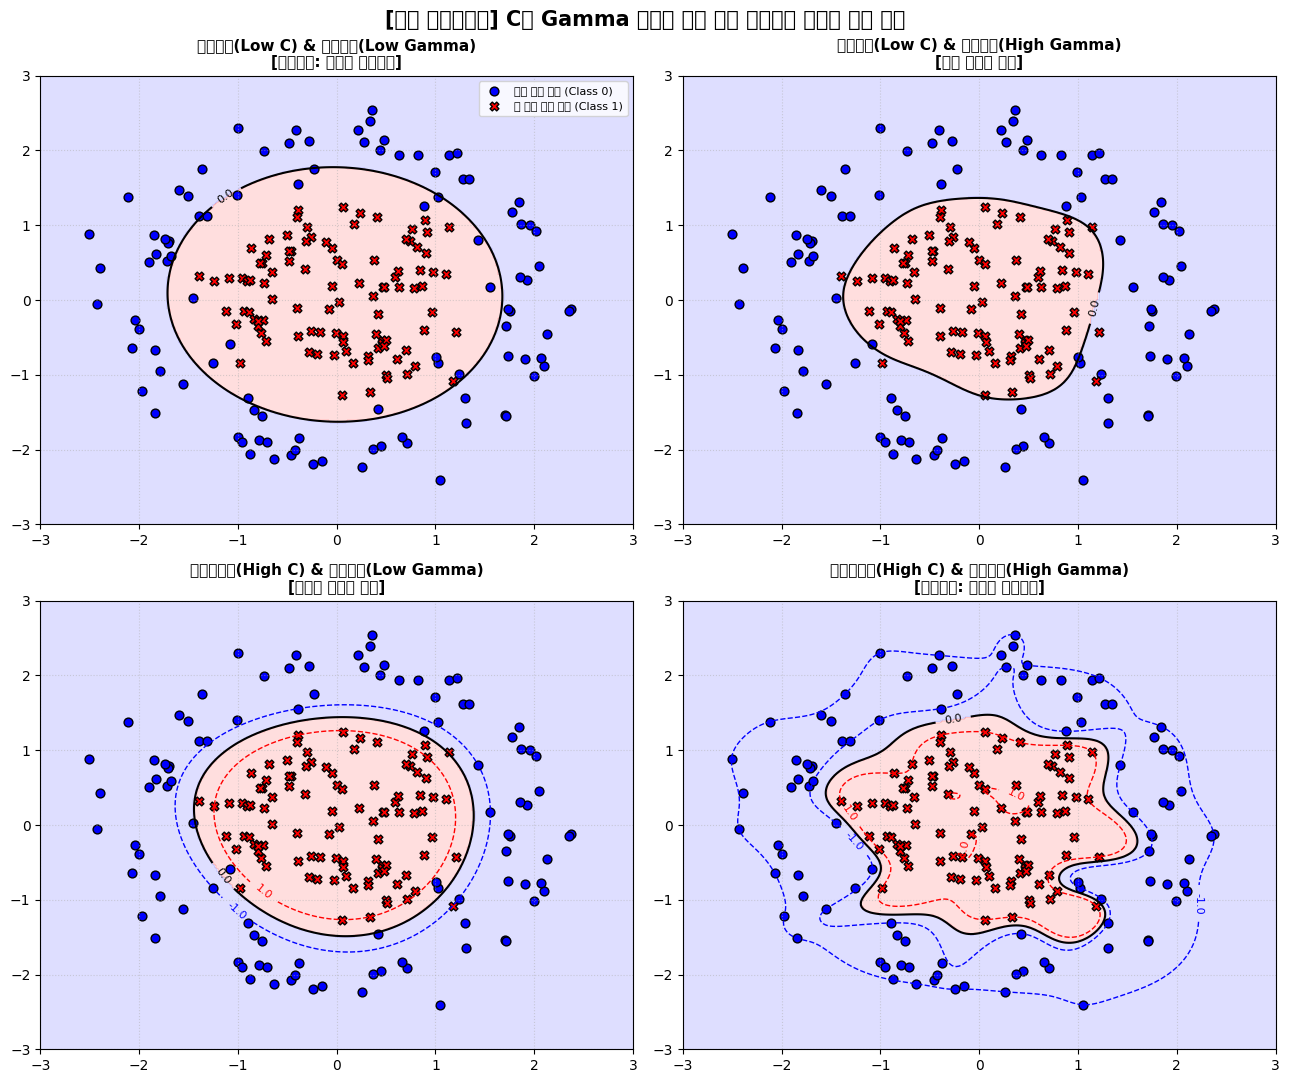

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 글로벌 시드 고정 (군 전술 실험 재현성 확보)
np.random.seed(42)

def generate_tactical_defense_data():
    """
    [군 작전 시나리오 데이터]
    - Class 0 (Blue): 아군 핵심 방어 진지 및 안전 구역 (안쪽)
    - Class 1 (Red/Green): 진지를 포위망 형태로 압박하는 적 침투 위험 구역 (바깥쪽)
    """
    X, y = make_circles(n_samples=200, noise=0.15, factor=0.4, random_state=42)
    # 군사 지도 좌표 느낌을 주기 위해 스케일링 조절 (예: GPS 오프셋 등)
    X = X * 2.0
    return X, y

def analyze_svm_hyperplane_shadow():
    """
    C(작전 규율 강도)와 Gamma(작전 반경)에 따른
    고차원 초평면의 2차원 작전지도 투영(Shadow) 실험
    """
    X_tactical, y_tactical = generate_tactical_defense_data()

    fig, axes = plt.subplots(2, 2, figsize=(13, 11))

    # 군사적 관점의 파라미터 해석 가미
    tactical_scenarios = [
        {"C": 0.01, "gamma": 0.1, "title": "교범위주(Low C) & 광역감시(Low Gamma)\n[언더피팅: 과도한 완충지대]"},
        {"C": 0.01, "gamma": 5.0, "title": "교범위주(Low C) & 국소경계(High Gamma)\n[고립 경계선 발생]"},
        {"C": 100.0, "gamma": 0.1, "title": "융통성제로(High C) & 광역감시(Low Gamma)\n[강경한 직선적 타협]"},
        {"C": 100.0, "gamma": 5.0, "title": "융통성제로(High C) & 국소경계(High Gamma)\n[오버피팅: 진지별 각개전투]"}
    ]

    # 작전 지도 격자 생성
    x0s = np.linspace(-3.0, 3.0, 250)
    x1s = np.linspace(-3.0, 3.0, 250)
    x0, x1 = np.meshgrid(x0s, x1s)
    X_map = np.c_[x0.ravel(), x1.ravel()]

    for idx, sc in enumerate(tactical_scenarios):
        row, col = idx // 2, idx % 2
        ax = axes[row, col]

        # 전술 데이터 표준화 및 RBF SVM 모델 빌드
        clf = Pipeline([
            ("scaler", StandardScaler()),
            ("svm", SVC(kernel="rbf", C=sc["C"], gamma=sc["gamma"]))
        ])
        clf.fit(X_tactical, y_tactical)

        # 2차원 투영 평면 계산 (Decision Boundary & Shadow Contours)
        y_pred = clf.predict(X_map).reshape(x0.shape)
        y_decision = clf.decision_function(X_map).reshape(x0.shape)

        # 고차원 칼질이 2차원 지도로 내려앉은 등고선 (Projection)
        ax.contourf(x0, x1, y_pred, cmap=plt.cm.bwr, alpha=0.15)

        # 마진 경계선 (-1, 0, 1) 시각화
        contour = ax.contour(x0, x1, y_decision, levels=[-1, 0, 1],
                             colors=['blue', 'black', 'red'], linestyles=['--', '-', '--'], linewidths=[1, 1.5, 1])
        ax.clabel(contour, inline=True, fontsize=8, fmt='%1.1f')

        # 군사 기호 대용 산점도 (아군 vs 적군)
        ax.scatter(X_tactical[y_tactical==0, 0], X_tactical[y_tactical==0, 1],
                   c='blue', marker='o', edgecolors='k', s=40, label="아군 통제 구역 (Class 0)")
        ax.scatter(X_tactical[y_tactical==1, 0], X_tactical[y_tactical==1, 1],
                   c='red', marker='X', edgecolors='k', s=40, label="적 침투 위험 구역 (Class 1)")

        ax.set_title(sc["title"], fontsize=11, fontweight='bold')
        ax.grid(True, linestyle=':', alpha=0.5)
        if idx == 0:
            ax.legend(loc="upper right", fontsize=8)

    plt.suptitle("[전술 시뮬레이션] C와 Gamma 변화에 따른 방어 초평면의 저차원 투영 착시",
                 fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    analyze_svm_hyperplane_shadow()